In [1]:
import os
import torch
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset, Subset, SubsetRandomSampler
from torchvision import datasets, transforms, models 
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import random

In [2]:
lung_dataset = '../lung_colon_image_set/lung_image_sets'
colon_dataset = '../lung_colon_image_set/colon_image_sets'
if not os.path.exists(lung_dataset):
    raise FileNotFoundError(f"Dataset path {lung_dataset} does not exist!")
if not os.path.exists(colon_dataset):
    raise FileNotFoundError(f"Dataset path {colon_dataset} does not exist!")

lung_classes=sorted(os.listdir(lung_dataset))
colon_classes=sorted(os.listdir(colon_dataset))

print(f"Classes found: {lung_classes} and {colon_classes}")

all_classes = sorted(set(lung_classes + colon_classes))
print(f"Combined classes: {all_classes}")

Classes found: ['lung_aca', 'lung_n', 'lung_scc'] and ['colon_aca', 'colon_n']
Combined classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [3]:
def prepare_splits(datadirs, split_ratios=(0.8, 0.1, 0.1)):
    all_data = {}
    for datadir in datadirs:
        for cls in sorted(os.listdir(datadir)):
            class_dir = os.path.join(datadir, cls)
            if os.path.isdir(class_dir):
                all_data.setdefault(cls, []).extend(
                    os.path.join(class_dir,fname) for fname in os.listdir(class_dir)
                )
    
    splits = {'train': [], 'val': [], 'test': []}
    
    for cls, files in all_data.items():
        train_files, temp_files = train_test_split(files, test_size=(1 - split_ratios[0]), random_state=42)
        
        val_files, test_files = train_test_split(temp_files, test_size=split_ratios[2]/(split_ratios[1] + split_ratios[2]), random_state=42)
        
        splits['train'].extend(train_files)
        splits['val'].extend(val_files)
        splits['test'].extend(test_files)
        
    return splits

dataset_dirs = [lung_dataset, colon_dataset]
data_splits = prepare_splits(dataset_dirs)

print(f"Training samples: {len(data_splits['train'])}")
print(f"Validation samples: {len(data_splits['val'])}")
print(f"Testing samples: {len(data_splits['test'])}")

Training samples: 20000
Validation samples: 2500
Testing samples: 2500


In [5]:
class CombinedCancerDataset(Dataset):
    def __init__(self, file_paths, all_classes, transform=None):
        self.file_paths = file_paths
        self.all_classes = all_classes
        self.labels = [all_classes.index(os.path.basename(os.path.dirname(fp))) for fp in file_paths]
        self.transform = transform
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(random.randint(-45, 45)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])    

# Datasets
train_dataset = CombinedCancerDataset(data_splits['train'], all_classes, transform=transform)
val_dataset = CombinedCancerDataset(data_splits['val'], all_classes, transform=transform)
test_dataset = CombinedCancerDataset(data_splits['test'], all_classes, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [8]:
def train_model(model, train_loader, val_loader, num_epochs=3, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
    
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        epoch_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        val_losses.append (epoch_val_loss)
        val_accuracies.append(val_accuracy)
                
        val_accuracy = 100 * correct / total
        print(f"Validation Loss: {val_loss/len(val_loader)}, Validation Accuracy: {val_accuracy}")
    
    return train_losses, val_losses, val_accuracies

In [9]:
def ResNet_Definition(num_classes):
    model = models.resnet50(progress=False)
 
    model.fc = nn.Sequential(torch.nn.Linear(in_features=2048, out_features=num_classes))
 
    return model

In [10]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"Using device: {device}")

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Cuda availabel: {torch.cuda.is_available()}")
# print(f"Using device: {device}")

if __name__ == "__main__":
    model = ResNet_Definition(num_classes=len(all_classes)).to(device)
    train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader)

    print("Training abgeschlossen.")

MPS available: True
Using device: mps
Epoch 1, Loss: 0.4206345018103719
Validation Loss: 0.25898939264481474, Validation Accuracy: 88.72
Epoch 2, Loss: 0.22917348451837896
Validation Loss: 0.18764055244734265, Validation Accuracy: 92.24
Epoch 3, Loss: 0.18551139252334833
Validation Loss: 0.10475627785958432, Validation Accuracy: 95.44
Training abgeschlossen.


### Save model

In [11]:
# savving the model
save_path = './trainierte-modelle/resnet_model.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to ./trainierte-modelle/resnet_model.pth


### Visualisierung des Models

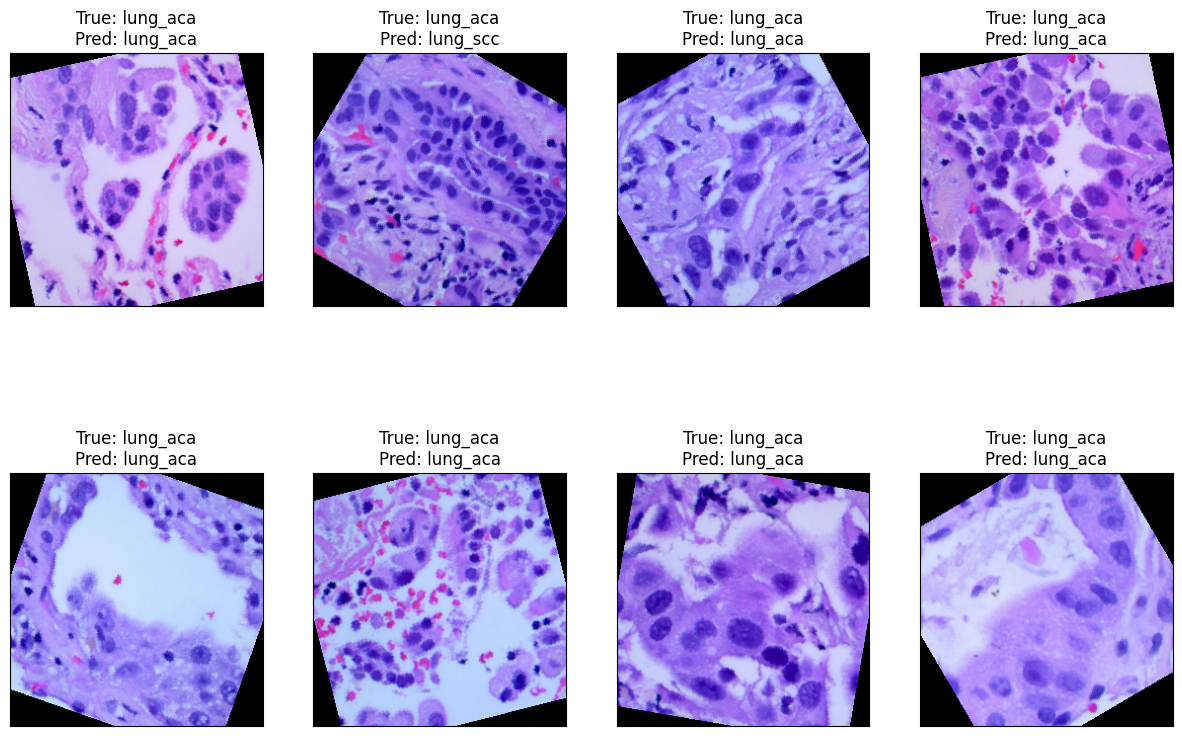

In [12]:
def visualize_predictions(model, test_loader, all_classes):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu()
    fig = plt.figure(figsize=(15, 10))
    for idx in range(8): 
        ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
        img = images[idx].permute(1, 2, 0)  
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  
        img = img.numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(f"True: {all_classes[labels[idx]]}\nPred: {all_classes[predicted[idx]]}")

    plt.show()


visualize_predictions(model, test_loader, all_classes)

### Testen

In [13]:
def test_model(model, test_loader):
    model.eval()
    test_correct = 0
    test_total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    test_accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    return all_labels, all_preds

all_labels, all_preds = test_model(model, test_loader)

Test Accuracy: 95.56%


### Confusion Matrix

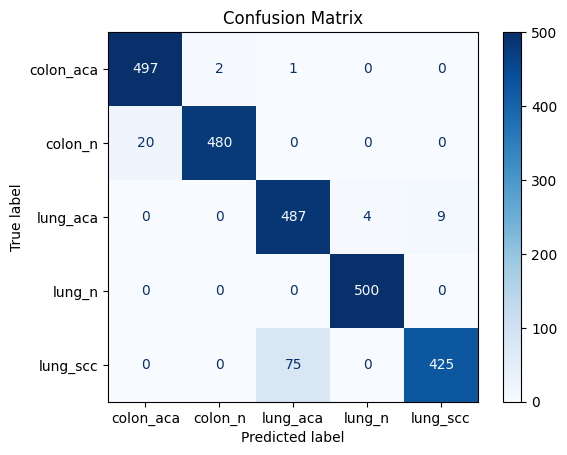

In [14]:
cm = confusion_matrix(all_labels, all_preds, labels=range(len(all_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

### XAI

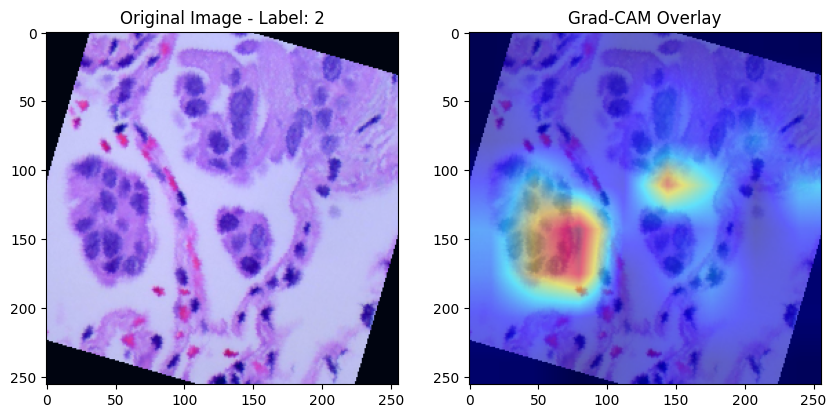

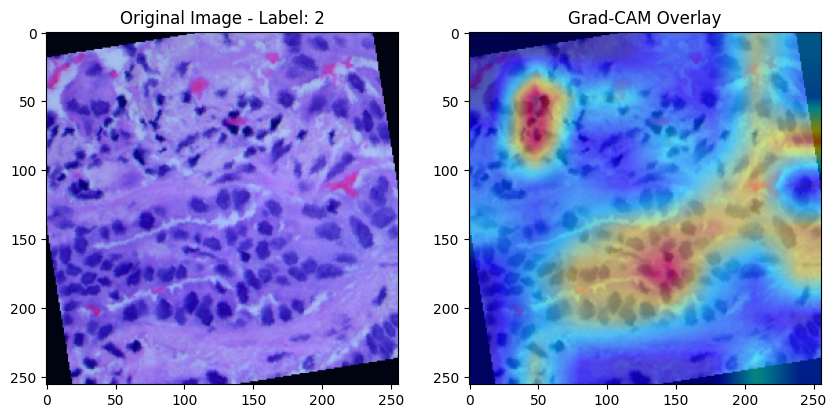

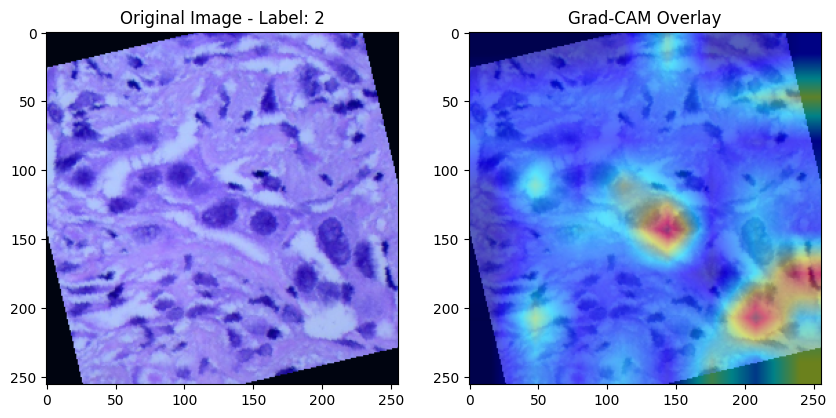

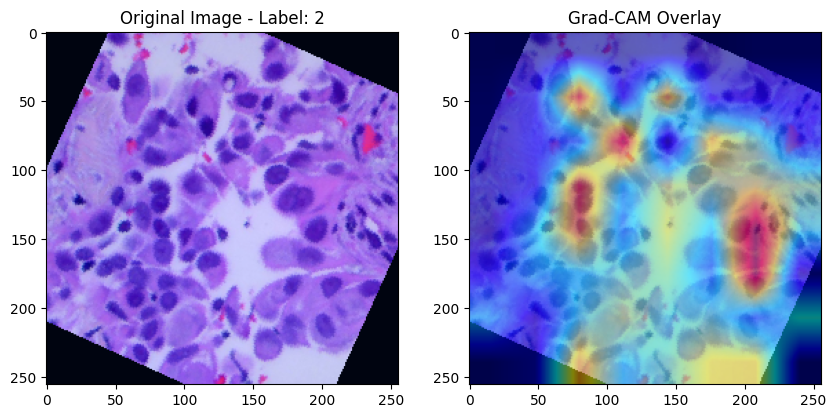

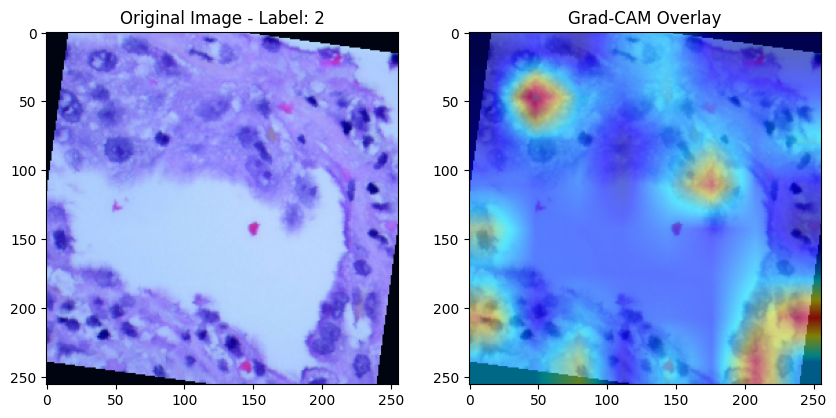

In [24]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(model, data_loader, target_layer):
    '''
    Visualize Grad-CAM for a batch of images from a data loader.
    Args:
        model (torch.nn.Module): The trained model to use for Grad-CAM.
        data_loader (torch.utils.data.DataLoader): DataLoader providing the images and labels.
        target_layer (torch.nn.Module): The target layer in the model for which Grad-CAM is computed.
    Returns:
        None: This function displays the original images and their corresponding Grad-CAM overlays.
    '''
    model.eval()
    images, labels = next(iter(data_loader))  
    images, labels = images.to(device), labels.to(device)
    
    cam = GradCAM(model=model, target_layers=[target_layer])
    
    for i in range(5):  
        input_tensor = images[i].unsqueeze(0) 
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        image_rgb = images[i].permute(1, 2, 0).cpu().numpy()
        image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
        
        cam_image = show_cam_on_image(image_rgb, grayscale_cam, use_rgb=True)
        
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image_rgb)
        plt.title(f"Original Image - Label: {labels[i].item()}")
        
        plt.subplot(1, 2, 2)
        plt.imshow(cam_image)
        plt.title(f"Grad-CAM Overlay")
        plt.show()

visualize_gradcam(model, test_loader, target_layer=model.layer4[-1]) 

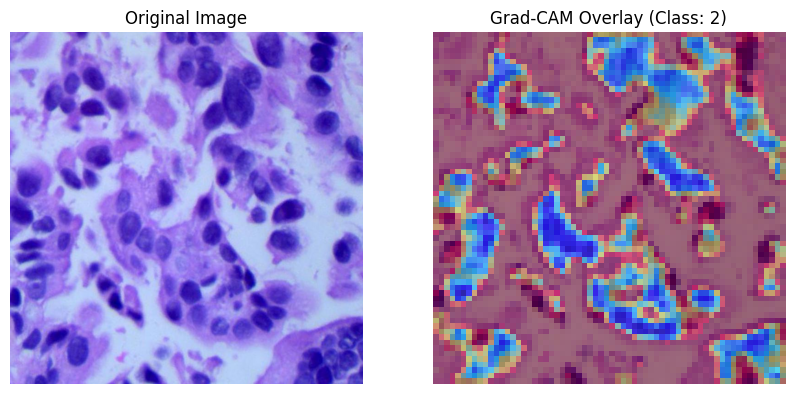

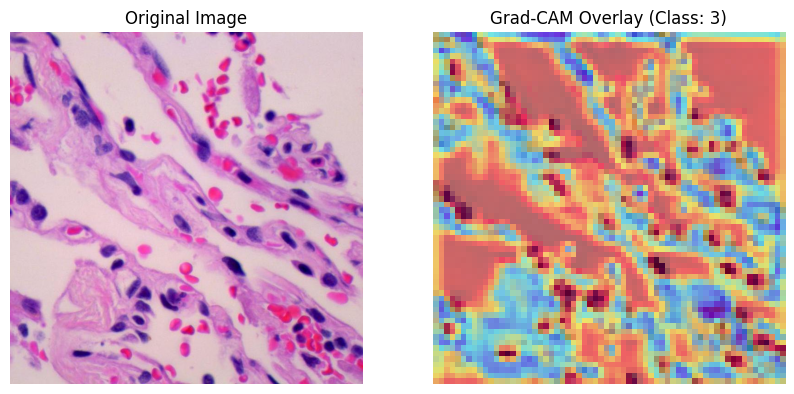

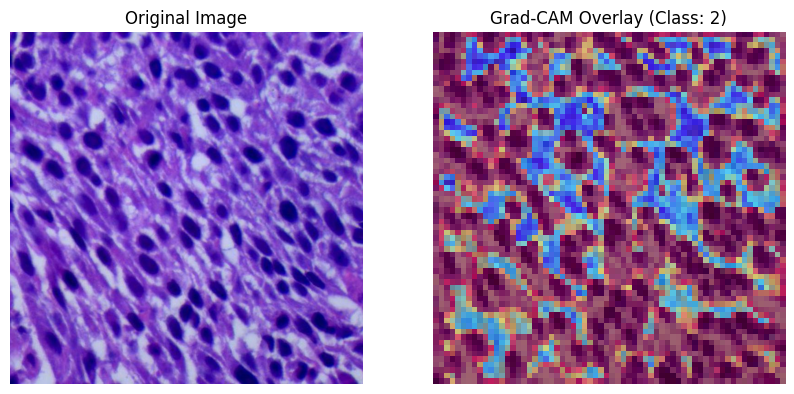

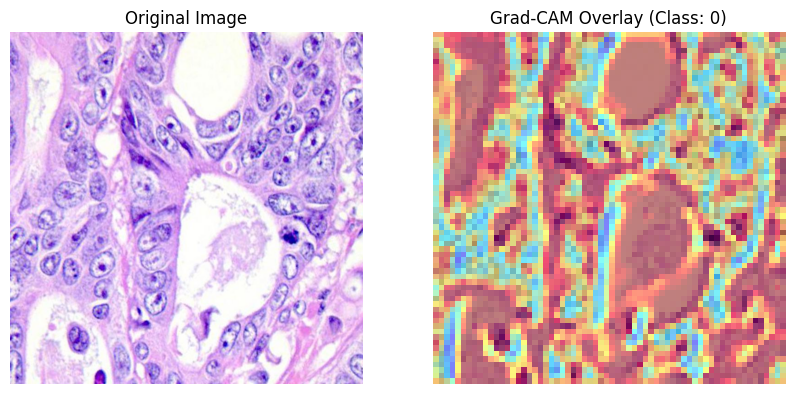

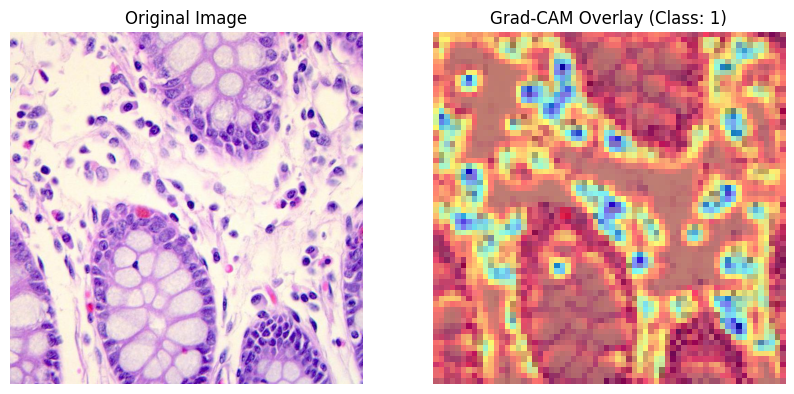

In [28]:
from captum.attr import LayerGradCam
import cv2

def visualize_gradcam_on_images_captum(model, image_paths, target_layer, device='cpu'):
    """
    Apply Grad-CAM using Captum on specific images given their file paths.

    Args:
        model (torch.nn.Module): The trained model.
        image_paths (list): List of paths to images.
        target_layer (torch.nn.Module): The target layer in the model.
        device (str): 'cpu' or 'cuda'.

    Returns:
        Displays the Grad-CAM visualizations.
    """

    # Image preprocessing - same as during training
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Ensure consistent input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    model.to(device)
    model.eval()
    
    # Initialize Captum Grad-CAM
    grad_cam = LayerGradCam(model, target_layer)

    for image_path in image_paths:
        # Load and preprocess image
        image = Image.open(image_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        # Forward pass to get the prediction
        output = model(input_tensor)
        pred_label = output.argmax(dim=1).item()  # Get the predicted class

        # Generate Grad-CAM heatmap
        attributions = grad_cam.attribute(input_tensor, target=pred_label)
        attributions = attributions.squeeze().cpu().detach().numpy()

        # Normalize attributions to [0, 1] range
        attributions = np.maximum(attributions, 0)  # ReLU operation
        attributions = attributions / (attributions.max() + 1e-8)  # Avoid division by zero

        # Convert image to NumPy format for visualization
        image_rgb = np.array(image) / 255.0  # Normalize to [0,1]
        image_resized = cv2.resize(image_rgb, (attributions.shape[1], attributions.shape[0]))  # Resize original image to match Grad-CAM

        # Ensure attributions are correctly formatted for OpenCV
        heatmap = np.uint8(255 * attributions)  # Convert to 8-bit (0-255)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Apply color map

        # Normalize and blend heatmap with original image
        heatmap = heatmap.astype(np.float32) / 255  # Normalize to 0-1
        cam_image = (heatmap * 0.5) + (image_resized * 0.5)  # Blend heatmap with original image

        # Display results
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cam_image)
        plt.title(f"Grad-CAM Overlay (Class: {pred_label})")
        plt.axis("off")

        plt.show()


# Example usage with your image paths
image_paths = [
    '../lung_colon_image_set/lung_image_sets/lung_aca/lungaca27.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_n/lungn378.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_scc/lungscc24.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_aca/colonca3874.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_n/colonn128.jpeg'
]

# Use the last convolutional layer of your model (modify if needed)
target_layer = model.layer1  # Change this to your model’s last convolutional layer

visualize_gradcam_on_images_captum(model, image_paths, target_layer, device=device)


100%|██████████| 1000/1000 [01:13<00:00, 13.63it/s]


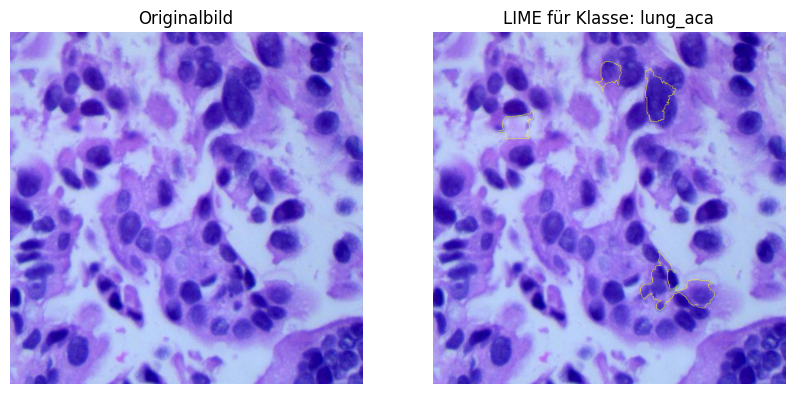

100%|██████████| 1000/1000 [01:18<00:00, 12.82it/s]


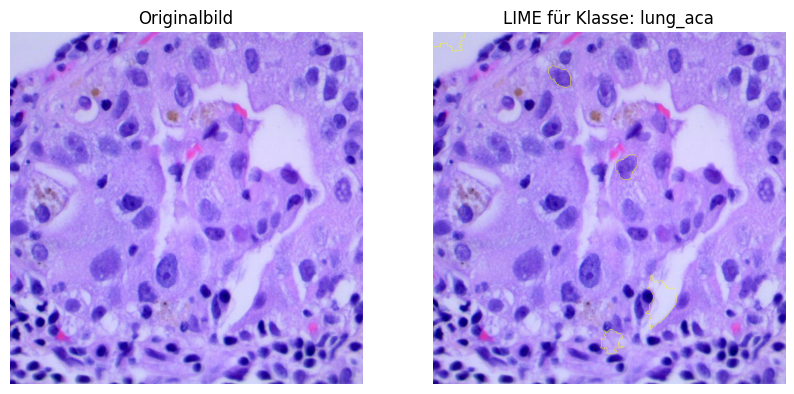

100%|██████████| 1000/1000 [01:10<00:00, 14.19it/s]


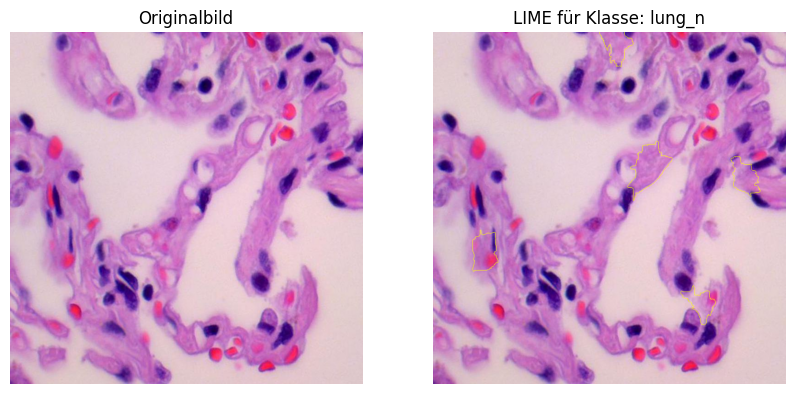

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_with_lime(model, image_path, all_classes, device='cpu'):
    """
    Erklärt eine CNN-Vorhersage für ein einzelnes Bild mit LIME.
    
    Args:
        model: Das trainierte CNN-Modell.
        image_path: Pfad zum Bild, das erklärt werden soll.
        all_classes: Liste der Klassennamen.
        device: 'cpu' oder 'cuda' für Berechnungen auf GPU/CPU.

    Returns:
        Zeigt das Originalbild und die LIME-Erklärung.
    """
    
    # Transformation wie beim Training
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Bild laden
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Sicherstellen, dass Modell im Eval-Modus ist
    model.eval()
    
    # LIME benötigt eine Funktion, die aus einem Bild ein Vorhersage-Array erzeugt
    def batch_predict(images):
        images = torch.stack([transform(Image.fromarray(img)) for img in images], dim=0).to(device)
        model.eval()
        with torch.no_grad():
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
        return probs

    # LIME-Explainer für Bilder
    explainer = lime_image.LimeImageExplainer()
    
    # Erklärung für das Bild
    explanation = explainer.explain_instance(
        np.array(image),
        batch_predict,
        top_labels=1,  # Nur die höchste Wahrscheinlichkeit analysieren
        hide_color=0,
        num_samples=1000  # Anzahl der generierten Perturbationen
    )

    # Visualisierung der wichtigsten Regionen
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,  # Nur aktivierende Pixel anzeigen
        num_features=5,  # Anzahl der hervorgehobenen Regionen
        hide_rest=False  # Andere Pixel nicht ausgrauen
    )

    # Darstellung
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Originalbild anzeigen
    ax[0].imshow(image)
    ax[0].set_title("Originalbild")
    ax[0].axis("off")
    
    # LIME-Erklärung mit Markierungen
    ax[1].imshow(mark_boundaries(temp, mask))
    ax[1].set_title(f"LIME für Klasse: {all_classes[explanation.top_labels[0]]}")
    ax[1].axis("off")
    
    plt.show()
    
def explain_multiple_images(model, image_paths, all_classes, device='cpu'):
    """
    Erklärt mehrere Bilder mit LIME und zeigt die Ergebnisse an.

    Args:
        model: Trainiertes CNN.
        image_paths: Liste von Bildpfaden.
        all_classes: Klassenliste.
        device: 'cpu' oder 'cuda'.

    Returns:
        Zeigt für jedes Bild eine LIME-Visualisierung.
    """
    for image_path in image_paths:
        explain_with_lime(model, image_path, all_classes, device)


image_paths = [
    '../lung_colon_image_set/lung_image_sets/lung_aca/lungaca27.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_n/lungn378.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_scc/lungscc234.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_aca/colonca3874.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_n/colonn198.jpeg'
]

explain_multiple_images(model, image_paths, all_classes, device=device)


Current image: ../lung_colon_image_set/lung_image_sets/lung_aca/lungaca27.jpeg
Original prediction: lung_aca with probability 0.9996


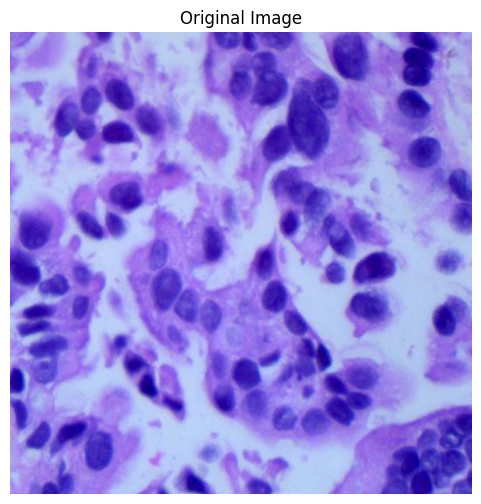

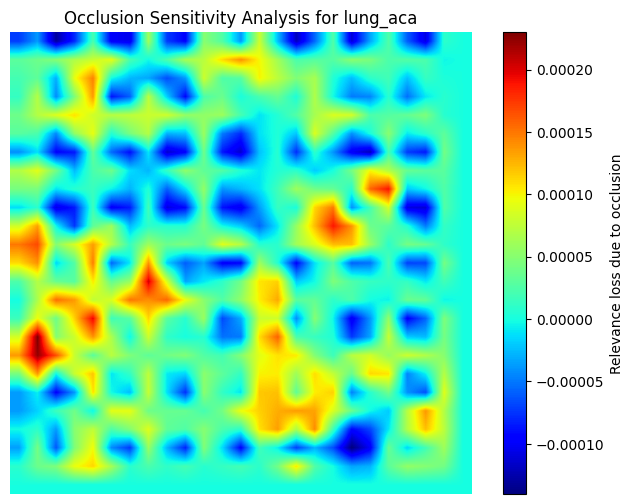

Current image: ../lung_colon_image_set/lung_image_sets/lung_aca/lungaca45.jpeg
Original prediction: lung_aca with probability 0.9377


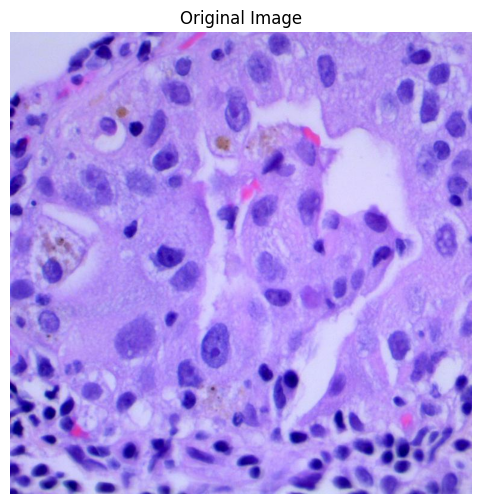

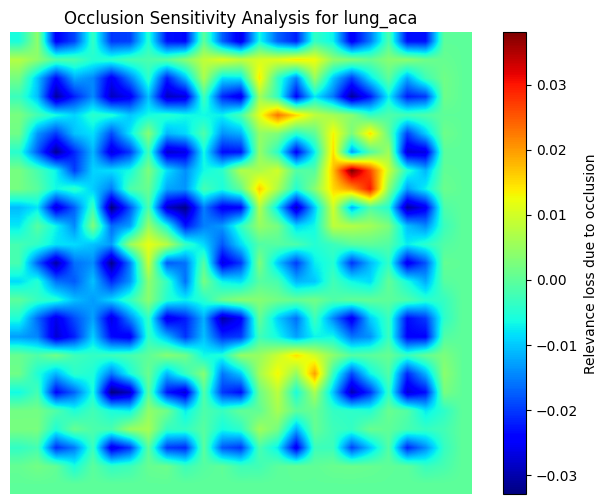

Current image: ../lung_colon_image_set/lung_image_sets/lung_n/lungn198.jpeg
Original prediction: lung_n with probability 1.0000


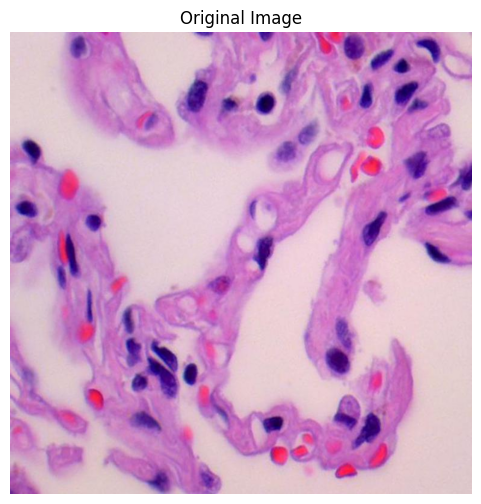

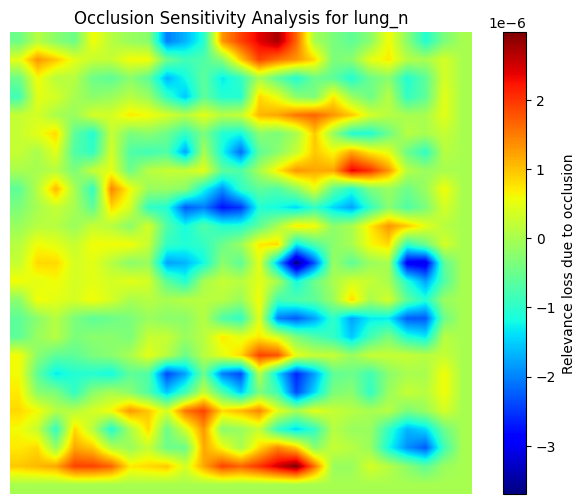

In [ ]:
def occlusion_sensitivity_analysis(model, image_path, all_classes, mask_size=20, stride=10, device='cpu'):
    """
    Performs an Occlusion Sensitivity Analysis (OSA) on an image.

    Args:
        model: The trained CNN model.
        image_path: Path to the image to be tested.
        all_classes: List of class names.
        mask_size: Size of the occluded area (e.g., 20x20 pixels).
        stride: Step size for moving the mask.
        device: 'cpu' or 'cuda'.

    Returns:
        Displays a heatmap of sensitivity to occlusion.
    """

    print(f"Current image: {image_path}")

    # Transformation as during training
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load and transform the image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Ensure the model is in evaluation mode
    model.eval()

    # Compute prediction on the original image
    with torch.no_grad():
        original_output = model(image_tensor)
        original_prob = torch.nn.functional.softmax(original_output, dim=1)
        predicted_class = torch.argmax(original_prob, dim=1).item()

    print(f"Original prediction: {all_classes[predicted_class]} with probability {original_prob[0][predicted_class]:.4f}")

    # Prepare occlusion matrix
    width, height = 256, 256  # Input image size after resize
    heatmap = np.zeros((height // stride, width // stride))

    # Iterate over the image and mask regions step by step
    for y in range(0, height - mask_size, stride):
        for x in range(0, width - mask_size, stride):
            # Copy of the image with blocked region
            occluded_image = image_tensor.clone()
            occluded_image[:, :, y:y+mask_size, x:x+mask_size] = 0  # Set pixels in region to 0 (black)

            # Model prediction on modified image
            with torch.no_grad():
                output = model(occluded_image)
                prob = torch.nn.functional.softmax(output, dim=1)[0, predicted_class].item()

            # Store the sensitivity value
            heatmap[y // stride, x // stride] = original_prob[0][predicted_class].item() - prob  # Compute difference
    
    
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
    
    # Plot the sensitivity heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap, cmap='jet', interpolation='bilinear')
    plt.colorbar(label="Relevance loss due to occlusion")
    plt.title(f"Occlusion Sensitivity Analysis for {all_classes[predicted_class]}")
    plt.axis("off")
    plt.show()

def occlusion_sensitivity_multiple_images(model, image_paths, all_classes, mask_size=20, stride=10, device='cpu'):
    """
    Performs Occlusion Sensitivity Analysis for multiple images.

    Args:
        model: The trained CNN model.
        image_paths: List of image paths.
        all_classes: List of class names.
        mask_size: Size of the occluded area.
        stride: Step size for moving the mask.
        device: 'cpu' or 'cuda'.

    Returns:
        Displays an OSA heatmap for each image.
    """
    for image_path in image_paths:
        occlusion_sensitivity_analysis(model, image_path, all_classes, mask_size, stride, device)

image_paths = [
    '../lung_colon_image_set/lung_image_sets/lung_aca/lungaca27.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_n/lungn378.jpeg',
    '../lung_colon_image_set/lung_image_sets/lung_scc/lungscc234.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_aca/colonca3874.jpeg',
    '../lung_colon_image_set/colon_image_sets/colon_n/colonn198.jpeg'
]

occlusion_sensitivity_multiple_images(model, image_paths, all_classes, mask_size=20, stride=10, device=device)